In [1]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False
DEBUG = True

DEBUG_QUERY = 400
DEBUG_L = 100

INF = 10**18

FILE_NUM = 100
# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(0)

if IS_ONLINE_JUDGE:
    DEBUG = False
# =================================
# 汎用
# =================================
import copy
import math
import random
from abc import ABC, abstractmethod
from collections import defaultdict
from sys import stdin

from common import (
    calc_centroid,
    calc_dist,
    calc_point_avg_distances,
    calc_rect_center,
    calc_rect_half_dist,
    calc_rectangle_area,
    clac_cross_point,
    construct_dist_matrix,
    construct_sorted_edges,
    exponential_schedule,
    get_four_points_from_rectangle,
    get_rect_edge,
    isin_rectangel,
    kruskals_algorithm,
    linear_schedule,
    prim,
    prim_k,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


std_input = lambda: stdin.readline()[:-1]


# =================================
# 環境
# =================================
class Env:
    N: int
    M: int
    Q: int
    L: int
    W: int
    G: list[int]
    rectangles: list[list[int]]
    cneter_points: list[tuple[float, float]]
    _query_history: list[str]

    @abstractmethod
    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        pass

    @abstractmethod
    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        pass

    def read_first_line(self, line: str):
        N, M, Q, L, W = map(int, line.split())
        self.N = N
        self.M = M
        self.Q = Q
        self.L = L
        self.W = W

    def read_second_line(self, lines: list[str]):
        self.G = list(map(int, lines[0].split()))

        rectangles = []
        for line in lines[1:]:
            rectangles.append(list(map(int, line.split())))
        self.rectangles = rectangles

        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]


class EnvOnline(Env):
    def __init__(self):
        self.read_first_line(std_input())
        self.read_second_line([std_input() for _ in range(self.N)])

        self._query_history: list[str] = []

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        print(query_str)
        return [tuple(map(int, std_input().split())) for _ in range(len(c_list) - 1)]

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
        print(ans_str)


class EnvOffline(Env):
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            self.read_first_line(lines[0])
            self.read_second_line(lines[1 : 2 + self.N])

            coordinates = []
            for l in range(2 + self.N, 2 + self.N * 2):
                coordinates.append(tuple(map(int, lines[l].split())))
            self.coordinates = coordinates

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path
        self._query_history: list[str] = []

        if DEBUG:
            self.L = DEBUG_L
            self.Q = DEBUG_QUERY

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)
        ans_edges, _ = kruskals_algorithm(construct_sorted_edges({v: self.coordinates[v] for v in c_list}))
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"

        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist
        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        if len(self._query_history) > self.Q:
            debug_print(f"!!!query limit exceeded {len(self._query_history)}/{self.Q}")
        else:
            debug_print(f"query: {len(self._query_history)}")

        return cost

やること

- 以下を持つオブジェクト
  - ソート済み辺(cost, a, b)
  - 対象頂点 set
  - 現在のエッジ
  - 正解のエッジ
  - 現在の誤りエッジ数
  - V = len(頂点 set)
  - 辺の更新(input: ソート済み更新辺)
    - 更新辺に含まれているエッジがあれば削除
    - 元の辺と、更新辺を前から捜査していき、小さい順に追加する
    - クラスカル法で現在のエッジを更新
    - V - 正解エッジ数を算出

全辺の総数 = (env.L - 1) / env.Q

- 1 点を更新する
  - cost = 0
  - 1 つの全域木 INFO for 全全域木 INFO
    - その全域木内の点が更新対象でないな
      - cost += 誤りエッジ数
    - 更新対象である
      - 更新点と、全域木内の点の距離を計算してエッジを作成
      - エッジをソート
      - 辺の更新メソッドを呼ぶ
      - cost += 誤りエッジ数
  - total_cost = cost / 全辺の総数


In [2]:
# =================================
# 以下メイン処理
# =================================
class MyGraph:
    def __init__(self, vs, edges, group_ind):
        self.vs = vs
        self.edges = edges
        self.group_ind = group_ind

        self.visited_cnt = {v: 0 for v in vs}
        self._construct_graph()

    def _construct_graph(self):
        graph = defaultdict(list)
        for i, e in enumerate(self.edges):
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])
        self.graph = graph

    def update_edges(self, remove_edge, add_edges):
        self.edges = list(set(self.edges) - set(remove_edge) | set(add_edges))
        self._construct_graph()

    def choice_min_visited(self):
        min_v = min(self.visited_cnt.values())
        min_vs = [v for v, cnt in self.visited_cnt.items() if cnt == min_v]
        return random.choice(min_vs)

    def walk_bfs(self, init_v, q_num):
        visited_v = set()
        visited_edge = set()
        q = [(None, init_v)]
        while q and len(visited_v) < q_num:
            random.shuffle(q)
            pv, v = q.pop()
            if v in visited_v:
                continue
            if pv is not None:
                visited_edge.add((min(pv, v), max(pv, v)))
            visited_v.add(v)
            for nv in self.graph[v]:
                if nv not in visited_v:
                    q.append((v, nv))

        for v in visited_v:
            self.visited_cnt[v] += 1

        return visited_v, visited_edge


class EstimatePoint:
    def __init__(self, rectangle, ind):
        self.rectangle = rectangle
        self.ind = ind
        self.move_cnt = 0
        self.estimate_coordinate = calc_rect_center(rectangle)

        self._can_move_dist = calc_rect_half_dist(rectangle)

    def random_move(self, move_dist_mul: float):
        # 現在の推測点からrandom_vector方向に、最大移動可能距離x倍率分だけ移動する。四角形の外に出ないようにする。
        random_x = random.uniform(-1, 1)
        random_y = random.uniform(-1, 1)
        random_vec = (random_x, random_y)
        move_dist = self._can_move_dist * move_dist_mul

        p1 = self.estimate_coordinate
        tmp_p2 = p1[0] + random_vec[0], p1[1] + random_vec[1]
        now_dist = calc_dist(p1, tmp_p2)
        dist = 1 / now_dist * move_dist
        p2 = p1[0] + random_vec[0] * dist, p1[1] + random_vec[1] * dist

        for edge in get_rect_edge(self.rectangle):
            cross_point = clac_cross_point((p1, p2), edge)
            if cross_point:
                self.estimate_coordinate = cross_point
                break

        if isin_rectangel(p2, self.rectangle):
            self.estimate_coordinate = p2


def calc_greedy_answer(env: EnvOffline, target_points):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges


def update_mst(env: EnvOffline, ans_v, ans_edges):
    group_query_cnt = [0 for _ in range(env.M)]
    group_query_v_cnt = [0 for _ in range(env.M)]

    largest_groups = []
    for g in range(env.M):
        if 3 <= len(ans_v[g]):
            group_query_cnt[g] += 1
            group_query_v_cnt[g] += env.L
            if env.L < len(ans_v[g]):
                largest_groups.append(g)

    for _ri in range(env.Q - sum(group_query_cnt)):
        min_cost = 10**9
        target_group = None
        for g in largest_groups:
            cost = group_query_v_cnt[g] / len(ans_v[g])
            if cost < min_cost:
                min_cost = cost
                target_group = g
        if target_group is not None:
            group_query_v_cnt[target_group] += env.L
            group_query_cnt[target_group] += 1

    for g in range(env.M):
        now_v = ans_v[g]
        now_edges = ans_edges[g]
        if len(now_v) < 3:
            if group_query_cnt[g] > 0:
                print(g, "ERROR")
            continue
        if 3 <= len(now_v) <= env.L:
            ans_edges[g] = env.query(now_v)
            continue

        my_graph = MyGraph(now_v, now_edges, g)
        for _ in range(group_query_cnt[g]):
            rand_v = my_graph.choice_min_visited()
            visited_v, visited_edge = my_graph.walk_bfs(rand_v, env.L)
            new_edges = env.query(visited_v)
            my_graph.update_edges(visited_edge, new_edges)
        ans_edges[g] = my_graph.edges

    return ans_v, ans_edges


# =================================
# 焼きなまし
# =================================
def calc_score(correct_vs_list, correct_edges_list, estimate_points: list[EstimatePoint]):
    """焼きなましのスコア計算"""
    correct_edge_num = 0
    all_edge_num = 0
    for now_correct_vs, now_correct_edge in zip(correct_vs_list, correct_edges_list):
        estimate_coords = {v: estimate_points[v].estimate_coordinate for v in now_correct_vs}
        ans_edges, _ = kruskals_algorithm(construct_sorted_edges(estimate_coords))

        correct_edges_set = set(now_correct_edge)
        estimate_edges_set = set(ans_edges)
        correct_edge_num += len(correct_edges_set & estimate_edges_set)
        all_edge_num += len(estimate_edges_set)
    score = 1 - correct_edge_num / all_edge_num
    return score


def neighbor_function(estimate_points: list[EstimatePoint], now_dist_mul):
    """近傍解"""
    ret_estimate_points = copy.deepcopy(estimate_points)
    for _ in range(10):
        N = len(ret_estimate_points)
        random_ind = random.randint(0, N - 1)
        ret_estimate_points[random_ind].random_move(now_dist_mul)
    return ret_estimate_points


def simulated_annealing(
    corrct_vs_list,
    correct_edges_list,
    estimate_points: list[EstimatePoint],
    initial_temp: float,
    init_dist: float,
    min_dist: float,
    min_temp: float,
    max_time: float,
    display: bool,
) -> tuple[tuple[list[int], list[int]], float]:
    esp = 0.01
    x = estimate_points
    current_cost = calc_score(corrct_vs_list, correct_edges_list, x)  # 初期解のコストを計算
    if current_cost <= esp:
        return x
    best_x = x
    best_cost = current_cost

    start_time = time.perf_counter()  # 開始時刻を記録
    iteration = 0

    while True:
        elapsed_time = time.perf_counter() - start_time
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(initial_temp, min_temp, elapsed_time, max_time)
        now_dist_mul = linear_schedule(init_dist, min_dist, elapsed_time, max_time)
        if temp < min_temp:
            break

        # 近傍解を生成
        new_x = neighbor_function(x, now_dist_mul)
        new_cost = calc_score(corrct_vs_list, correct_edges_list, new_x)
        if new_cost <= esp:
            debug_print(f"Iteration: {iteration}, Best cost: {new_cost}")
            return new_x
        delta_cost = new_cost - current_cost

        # 改善されるなら更新、悪化しても確率的に更新
        if delta_cost < 0 or random.random() < math.exp(-delta_cost / temp):
            x = new_x
            current_cost = new_cost

        # 最良解の更新
        if current_cost < best_cost:
            best_x = x
            best_cost = current_cost

        iteration += 1
        if display and iteration % 100 == 0:
            debug_print(f"Iteration: {iteration}, Best cost: {best_cost}, Current cost: {current_cost}")

    return best_x


def solve(env: EnvOffline):
    ans_v, ans_edges = calc_greedy_answer(env)
    ans_v, ans_edges = update_mst(env, ans_v, ans_edges)
    return env.answer(ans_v, ans_edges)


def main():
    if IS_ONLINE_JUDGE:
        env = EnvOnline()
        solve(env)
    else:
        costs = []
        for file_num in range(FILE_NUM):
            debug_print("=====")
            start_time = time.perf_counter()
            input_file_path = f"../in/{file_num:04d}.txt"
            output_file_path = f"../out/{file_num:04d}.txt"
            #####
            env = EnvOffline(input_file_path, output_file_path)
            cost = solve(env)
            #####
            debug_print(f"[{file_num}/{FILE_NUM}]: {cost} {time.perf_counter() - start_time:.2f}s")
            costs.append(cost)
        avg = sum(costs) / len(costs)
        debug_print(f"avg: {avg}")
        debug_print(f"max: {max(costs)}")
        with open("../result/mst_test02_rect.txt", "w") as f:
            f.write(f"avg: {avg}\n")
            for pi, cost in enumerate(costs):
                f.write(f"{pi:0<4} {cost}\n")

In [3]:
file_num = 0
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
#####
env = EnvOffline(input_file_path, output_file_path)

In [4]:
estimate_points: list[EstimatePoint] = []
for i, rect in enumerate(env.rectangles):
    estimate_points.append(EstimatePoint(rect, i))

random_vs_list = []
random_edges_list = []
for _ in range(400):
    vs = list(range(env.N))
    random_vs = random.choices(vs, k=15)
    mst_edges = env.query(random_vs)
    random_vs_list.append(random_vs)
    random_edges_list.append(mst_edges)

corrects = [env.coordinates[i] for i in random_vs]
estimates = [estimate_points[i].estimate_coordinate for i in random_vs]

opt_estimate_points = simulated_annealing(
    corrct_vs_list=random_vs_list,
    correct_edges_list=random_edges_list,
    estimate_points=estimate_points,
    initial_temp=(1 / (100 * 100)),
    min_temp=(1 / (100 * 100)) * 0.001,
    init_dist=1,
    min_dist=0.001,
    max_time=20,
    display=True,
)

Iteration: 100, Best cost: 0.14159610880922358, Current cost: 0.14159610880922358
Iteration: 200, Best cost: 0.1324085750315258, Current cost: 0.1324085750315258


In [5]:
corrects = [env.coordinates[i] for i in range(env.N)]
estimates = [opt_estimate_points[i].estimate_coordinate for i in range(env.N)]
print(calc_point_avg_distances(env.coordinates, env.cneter_points))
print(calc_point_avg_distances(env.coordinates, estimates))
anv_v, ans_edges = calc_greedy_answer(env, estimates)
env.answer(anv_v, ans_edges)

260.49903699978677
275.4422556857701
query: 400


345052.69655639236

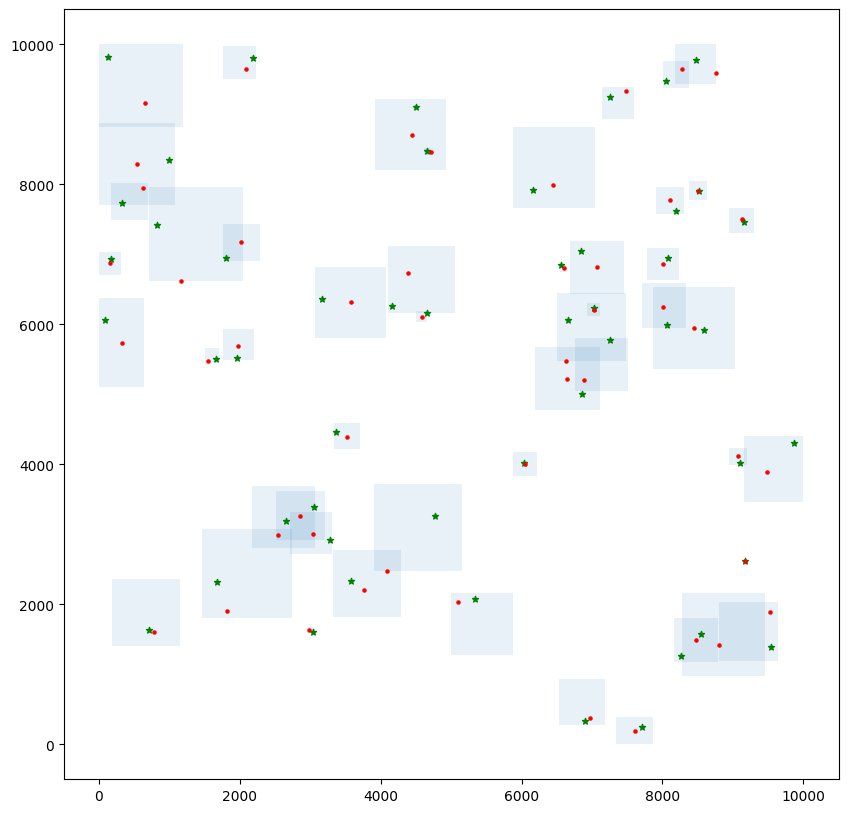

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

N = 50
corrects_np = np.array(corrects[:N])
estimates_np = np.array(estimates[:N])
rectangles = [env.rectangles[i] for i in range(N)]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
for i, rect in enumerate(rectangles):
    l, r, t, b = rect
    ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
plt.show()